In [1]:
!pip install ortools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 16.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
tensorflow 2.19.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatibl

In [2]:
import pandas as pd
from ortools.linear_solver import pywraplp

In [12]:
df = pd.read_csv("NewYork_SAHIE_PivotTable.csv")

In [13]:
# Filter
df = df[
    (df["agecat"] == 5) &   # 21–64
    (df["racecat"] == 0) &  # all races
    (df["sexcat"] == 0) &   # both sexes
    (df["iprcat"] == 1) &    # low-income (<=200% poverty)
    (df["year"] == 2023)
]

# Keep relevant columns
df = df[["countyfips", "county_name", "NUI", "PCTUI", "NIPR"]].copy()

# Normalize PCTUI (convert from % to fraction)
df["PCTUI"] = df["PCTUI"] / 100.0

# Paramters
B = 1000          # total budget
K = 10            # max number of counties to target
M = 100           # big-M (max allocation per county)
k = 10            # scaling factor for effectiveness

# Compute alpha (effectiveness)
df["alpha"] = k * df["PCTUI"]

counties = df.index.tolist()

# --- SOLVER ---
solver = pywraplp.Solver.CreateSolver("SCIP")

# Decision variables
x = {}
y = {}

for i in counties:
    x[i] = solver.NumVar(0, M, f"x_{i}")      # resource allocation
    y[i] = solver.BoolVar(f"y_{i}")           # select county

# --- OBJECTIVE ---
solver.Maximize(
    solver.Sum(df.loc[i, "alpha"] * x[i] for i in counties)
)

# --- CONSTRAINTS ---

# Budget
solver.Add(solver.Sum(x[i] for i in counties) <= B)

# Selection constraint
for i in counties:
    solver.Add(x[i] <= M * y[i])

# Limit number of counties
solver.Add(solver.Sum(y[i] for i in counties) <= K)

# Cannot exceed uninsured population (optional scaling)
for i in counties:
    solver.Add(x[i] <= df.loc[i, "NUI"])

# --- SOLVE ---
status = solver.Solve()

# --- OUTPUT ---
if status == pywraplp.Solver.OPTIMAL:
    print("Optimal solution found!\n")

    total_newly_insured = 0

    for i in counties:
        if y[i].solution_value() > 0.5:
            alloc = x[i].solution_value()
            alpha = df.loc[i, "alpha"]
            newly_insured = alpha * alloc

            total_newly_insured += newly_insured

            print(f"{df.loc[i, 'county_name'].strip()}:")
            print(f"  Allocation: {alloc:.2f}")
            print(f"  Estimated newly insured: {newly_insured:.2f}\n")

    print(f"Total newly insured: {total_newly_insured:.2f}")
else:
    print("No optimal solution found.")

Optimal solution found!

Dutchess County:
  Allocation: 100.00
  Estimated newly insured: 126.00

Nassau County:
  Allocation: 100.00
  Estimated newly insured: 135.00

Orange County:
  Allocation: 100.00
  Estimated newly insured: 132.00

Putnam County:
  Allocation: 100.00
  Estimated newly insured: 142.00

Queens County:
  Allocation: 100.00
  Estimated newly insured: 159.00

Rockland County:
  Allocation: 100.00
  Estimated newly insured: 150.00

Suffolk County:
  Allocation: 100.00
  Estimated newly insured: 144.00

Ulster County:
  Allocation: 100.00
  Estimated newly insured: 159.00

Westchester County:
  Allocation: 100.00
  Estimated newly insured: 152.00

Yates County:
  Allocation: 100.00
  Estimated newly insured: 178.00

Total newly insured: 1477.00


In [14]:
results = []

for i in counties:
    alloc = x[i].solution_value()
    alpha = df.loc[i, "alpha"]
    z = alpha * alloc

    NUI_old = df.loc[i, "NUI"]
    NIPR = df.loc[i, "NIPR"]

    NUI_new = max(NUI_old - z, 0)
    pct_new = NUI_new / NIPR

    results.append({
        "county": df.loc[i, "county_name"],
        "old_pct": df.loc[i, "PCTUI"],
        "new_pct": pct_new
    })

results_df = pd.DataFrame(results)

In [16]:
results_df

,county,old_pct,new_pct
0,...,0.116,0.116244
1,Albany County ...,0.100,0.100333
2,Allegany County ...,0.093,0.093097
3,Bronx County ...,0.110,0.109786
4,Broome County ...,0.099,0.099075
...,...,...,...
58,Washington County ...,0.086,0.086390
59,Wayne County ...,0.116,0.115906
60,Westchester County ...,0.152,0.150643
61,Wyoming County ...,0.093,0.092773


In [24]:
results_df.to_csv('results.csv', index=False)
print('results.csv exported successfully!')

results.csv exported successfully!


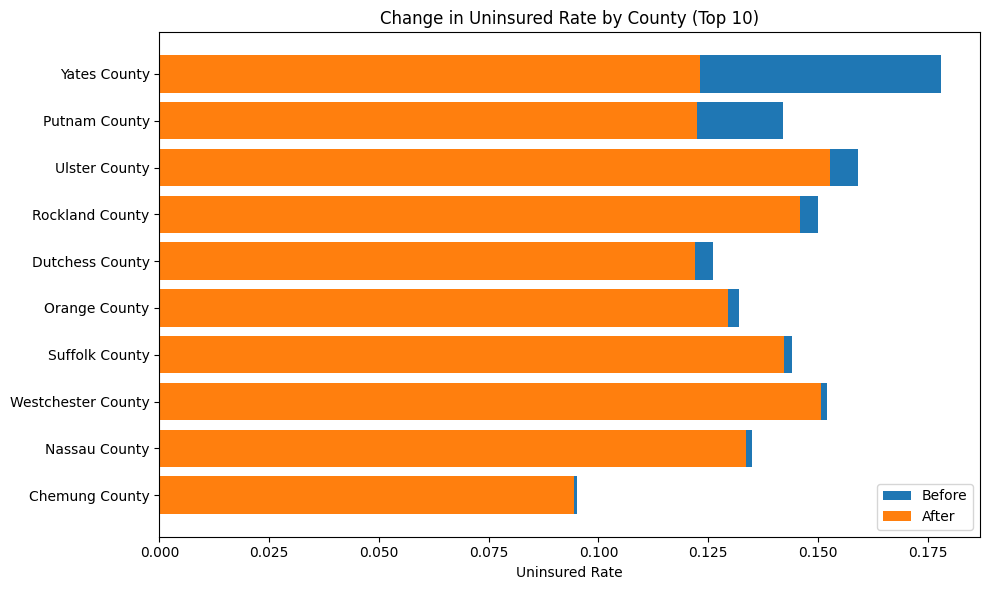

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Clean county names
plot_df = results_df.copy()
plot_df["county"] = plot_df["county"].str.strip()

# Remove any blank rows
plot_df = plot_df[plot_df["county"] != ""]

# Compute reduction
plot_df["reduction"] = plot_df["old_pct"] - plot_df["new_pct"]

# Take top 10 most impacted counties
plot_df = plot_df.sort_values(by="reduction", ascending=False).head(10)

# Reverse for better plotting order
plot_df = plot_df[::-1]

# Positions
y = np.arange(len(plot_df))

# Plot
plt.figure(figsize=(10,6))

plt.barh(y, plot_df["old_pct"], label="Before")
plt.barh(y, plot_df["new_pct"], label="After")

# Labels
plt.yticks(y, plot_df["county"])
plt.xlabel("Uninsured Rate")
plt.title("Change in Uninsured Rate by County (Top 10)")

plt.legend()

plt.tight_layout()
plt.show()